In [1]:
!pip install altair vega_datasets

In [2]:
import pandas as pd
import altair as alt
url = "https://raw.githubusercontent.com/wri/global-power-plant-database/master/output_database/global_power_plant_database.csv"
df = pd.read_csv(url, low_memory=False)
df_clean = df.dropna(subset=['commissioning_year', 'capacity_mw', 'primary_fuel'])

top_fuels = df_clean['primary_fuel'].value_counts().nlargest(8).index
df_filtered = df_clean[df_clean['primary_fuel'].isin(top_fuels)].copy()

df_filtered['commissioning_year'] = pd.to_datetime(df_filtered['commissioning_year'], format='%Y')

selection = alt.selection_multi(fields=['primary_fuel'], bind='legend')

chart = alt.Chart(df_filtered).mark_circle(size=60).encode(
    x=alt.X('commissioning_year:T', 
            title='Year Plant Opened',
            axis=alt.Axis(grid=False, labelFlush=True)),
    y=alt.Y('capacity_mw:Q', 
            title='Generating Capacity (Megawatts)',
            scale=alt.Scale(type='log'), # Log scale helps see small solar vs giant nuclear
            axis=alt.Axis(format='.0f')),
    color=alt.Color('primary_fuel:N', 
                    title='Fuel Type',
                    scale=alt.Scale(scheme='tableau10')), # Public-friendly colors
    tooltip=[
        alt.Tooltip('name:N', title='Plant Name'),
        alt.Tooltip('country_long:N', title='Country'),
        alt.Tooltip('primary_fuel:N', title='Fuel'),
        alt.Tooltip('capacity_mw:Q', title='Capacity (MW)', format=',.1f'),
        alt.Tooltip('commissioning_year:T', title='Opened', format='%Y')
    ],
    opacity=alt.condition(selection, alt.value(0.7), alt.value(0.05))
).properties(
    width='container', # Makes the chart responsive for your Jekyll page
    height=450,
    title=alt.TitleParams(
        text="The Global Energy Timeline",
        subtitle=["Visualizing plant capacity over time. Click the legend to filter by fuel type."],
        anchor='start',
        fontSize=20,
        subtitleFontSize=14
    )
).add_selection(
    selection
).interactive() 

chart.save('main_viz.json')

print("Success: 'main_viz.json' generated. Upload this to your /assets/js/ folder.")

C:\Users\chifl\AppData\Local\Temp\ipykernel_34140\1577488912.py:22: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use selection_point instead.
  selection = alt.selection_multi(fields=['primary_fuel'], bind='legend')
C:\Users\chifl\AppData\Local\Temp\ipykernel_34140\1577488912.py:54: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use add_params instead.
  ).add_selection(


Success: 'main_viz.json' generated. Upload this to your /assets/js/ folder.


C:\Users\chifl\AppData\Local\Temp\ipykernel_34140\588372564.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=avg_cap, x='capacity_mw', y='primary_fuel', palette='viridis')


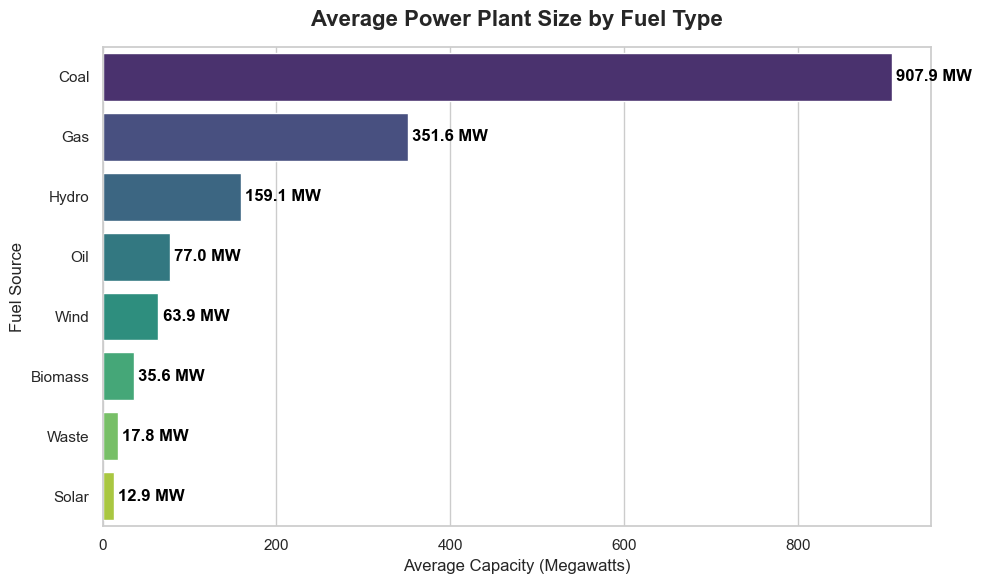

C:\Users\chifl\AppData\Local\Temp\ipykernel_34140\588372564.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(data=total_cap, x='capacity_mw', y='primary_fuel', palette='magma')


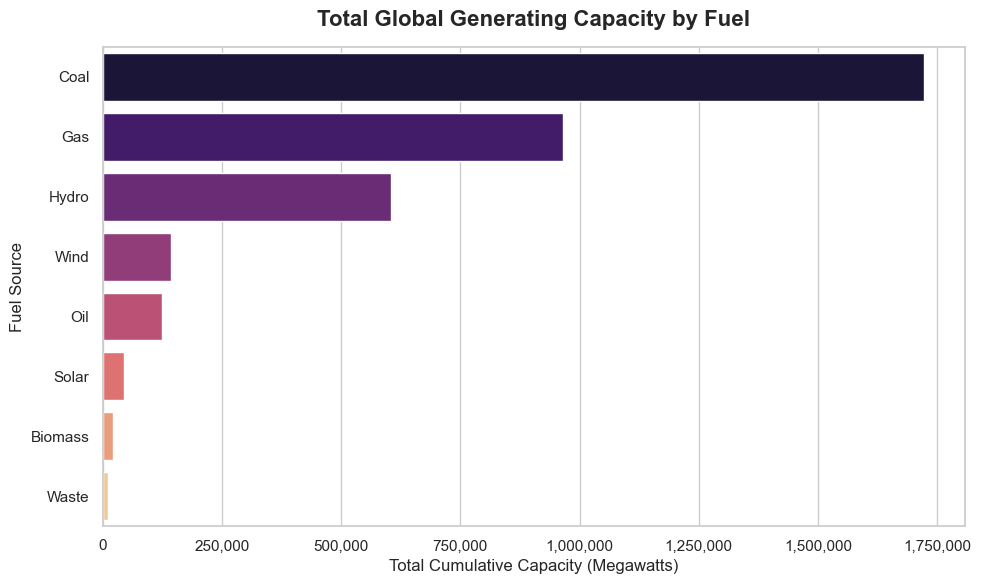

Success! 'fuel_capacity.png' and 'emissions_context.png' created from WRI data.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")

avg_cap = df_filtered.groupby('primary_fuel')['capacity_mw'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
ax1 = sns.barplot(data=avg_cap, x='capacity_mw', y='primary_fuel', palette='viridis')

plt.title('Average Power Plant Size by Fuel Type', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Average Capacity (Megawatts)', fontsize=12)
plt.ylabel('Fuel Source', fontsize=12)

for i, v in enumerate(avg_cap['capacity_mw']):
    ax1.text(v + 5, i, f'{v:.1f} MW', color='black', va='center', fontweight='semibold')

plt.tight_layout()
plt.savefig('fuel_capacity.png', dpi=300)
plt.show()


total_cap = df_filtered.groupby('primary_fuel')['capacity_mw'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
ax2 = sns.barplot(data=total_cap, x='capacity_mw', y='primary_fuel', palette='magma')

plt.title('Total Global Generating Capacity by Fuel', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Total Cumulative Capacity (Megawatts)', fontsize=12)
plt.ylabel('Fuel Source', fontsize=12)

from matplotlib.ticker import StrMethodFormatter
ax2.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.savefig('emissions_context.png', dpi=300) 
plt.show()

print("Success! 'fuel_capacity.png' and 'emissions_context.png' created from WRI data.")